In [1]:
# Csomag importálás, alapbeállítások

library(tidyverse)
library(recipes)
library(lubridate)
library(corrplot)
library(ggplot2)
library(dplyr)

options(repr.plot.width=8, repr.plot.height=6)

Warning message:
"package 'tidyverse' was built under R version 4.5.3"
Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'tidyr' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'dplyr' was built under R version 4.5.3"
Warning message:
"package 'forcats' was built under R version 4.5.3"
Warning message:
"package 'lubridate' was built under R version 4.5.3"
── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the con

In [2]:
# Adatok beolvasása

df = read_csv("./../data/apartment_data.csv",
              col_types=list(
                  currency = col_factor(),
                  bathrooms = col_double(),
                  bedrooms = col_double(),
                  price_display = col_double(),
                  square_feet = col_double()
              ))

Warning message:
"One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat)"


In [3]:
# Alapvető statisztikák az adathalmazról

summary(df)

   category            title               body            amenities        
 Length:99826       Length:99826       Length:99826       Length:99826      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
   bathrooms        bedrooms          currency         fee           
 Min.   :1.000   Min.   :0.000   USD      :99820   Length:99826      
 1st Qu.:1.000   1st Qu.:1.000   Cats,Dogs:    1   Class :character  
 Median :1.000   Median :2.000   1019     :    1   Mode  :character  
 Mean   :1.445   Mean   :1.728   NA's     :    4                     
 3rd Qu.:2.000   3rd Qu.:2.000    

In [5]:
# Vizsgálat a hibákra
glimpse(df)

head(problems(df), 20)

Rows: 99,826
Columns: 21
$ category      <chr> "housing/rent/apartment", "housing/rent/apartment", "hou…
$ title         <chr> "One BR 507 & 509 Esplanade", "Three BR 146 Lochview Dri…
$ body          <chr> "This unit is located at 507 & 509 Esplanade, Redondo Be…
$ amenities     <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ bathrooms     <dbl> 1.0, 1.5, 2.0, 1.0, 1.0, 1.5, 2.0, 2.0, 1.0, 2.0, 2.5, 3…
$ bedrooms      <dbl> 1, 3, 3, 2, 1, 2, 2, 2, 2, 2, 3, 2, 2, 4, 3, 2, 1, 1, 3,…
$ currency      <fct> "USD", "USD", "USD", "USD", "USD", "USD", "USD", "USD", …
$ fee           <chr> "No", "No", "No", "No", "No", "No", "No", "No", "No", "N…
$ has_photo     <chr> "Thumbnail", "Thumbnail", "Thumbnail", "Thumbnail", "Thu…
$ pets_allowed  <chr> "Cats", "Cats,Dogs", NA, "Cats,Dogs", "Cats,Dogs", "Cats…
$ price         <dbl> 2195, 1250, 1395, 1600, 975, 1250, 1600, 1300, 795, 2150…
$ price_display <dbl> 2195, 1250, 1395, 1600, 975, 1250, 1600, 1300, 795, 2150…
$ price_type   

row,col,expected,actual,file
<int>,<int>,<chr>,<chr>,<chr>
6731,12,a double,"$1,560 Weekly",D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
7247,12,a double,$275 Monthly|Weekly,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
8810,5,a double,No,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
8810,6,a double,Thumbnail,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
8810,14,a double,NJ,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
33782,5,a double,No,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
33782,6,a double,Thumbnail,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
33782,14,a double,CA,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
50213,12,a double,"$8,500 Weekly",D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv


In [6]:
# Adattisztítás a summary alapján
dfc = df

# Adatok eltolódása miatt keletkezett sorok szűrése
# Minden sorban USD-nek kellene szerepellnie, így használható szűrésre
dfc = filter(dfc, currency == "USD")

# NA-k feltöltése/szűrése
dfc = drop_na(dfc, price, price_display, square_feet, latitude, longitude)
dfc = replace_na(dfc,
                 list(bathrooms = median(df$bathrooms, na.rm=TRUE),
                 bedrooms = median(df$bedrooms, na.rm=TRUE),
                 pets_allowed = "None"))

# Nem értelmezett értékek szűrése
dfc = filter(dfc,
             grepl("housing/rent", category, fixed = TRUE), # csak kiadó lakások legyenek
             price_type %in% c("Monthly", "Weekly")) # csak diszkrét kategóriák legyenek

# Kategorizálás
dfc = mutate(dfc,
             category = factor(category),
             fee = factor(fee),
             has_photo = factor(has_photo),
             pets_allowed = fct_collapse(pets_allowed,
                Yes = c("Cats", "Cats,Dogs", "Cats,Dogs,None", "Dogs"),
                No = c("None")),
             price_type = factor(price_type),
             state = factor(state),
             cityname = factor(cityname),
             source = factor(source))

# Felhasználatlan/felesleges mezők szűrése
dfc = select(dfc, -title, -body, -currency, -address)

summary(dfc)

# price_type-ban 1 érték maradt, kivehető
dfc = select(dfc, -price_type)

                           category      amenities           bathrooms    
 housing/rent                  :    7   Length:99762       Min.   :1.000  
 housing/rent/apartment        :99701   Class :character   1st Qu.:1.000  
 housing/rent/commercial/retail:   42   Mode  :character   Median :1.000  
 housing/rent/condo            :    3                      Mean   :1.445  
 housing/rent/home             :    4                      3rd Qu.:2.000  
 housing/rent/other            :    1                      Max.   :9.000  
 housing/rent/short_term       :    4                                     
    bedrooms      fee            has_photo     pets_allowed     price      
 Min.   :0.000   No :99561   No       : 9256   Yes:39148    Min.   :  100  
 1st Qu.:1.000   Yes:  201   Thumbnail:34348   No :60614    1st Qu.: 1014  
 Median :2.000               Yes      :56158                Median : 1350  
 Mean   :1.728                                              Mean   : 1527  
 3rd Qu.:2.000      

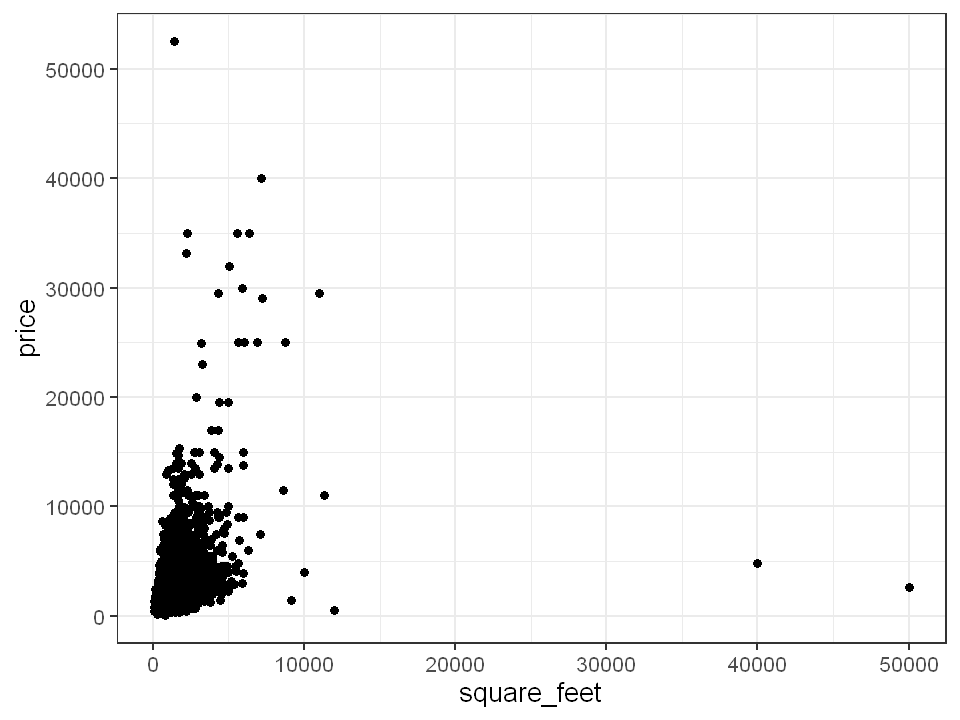

In [7]:
# Kiugró értékek keresése

ggplot(data = dfc) +
geom_point(mapping = aes(x = square_feet, y = price)) +
theme_bw(base_size=16)

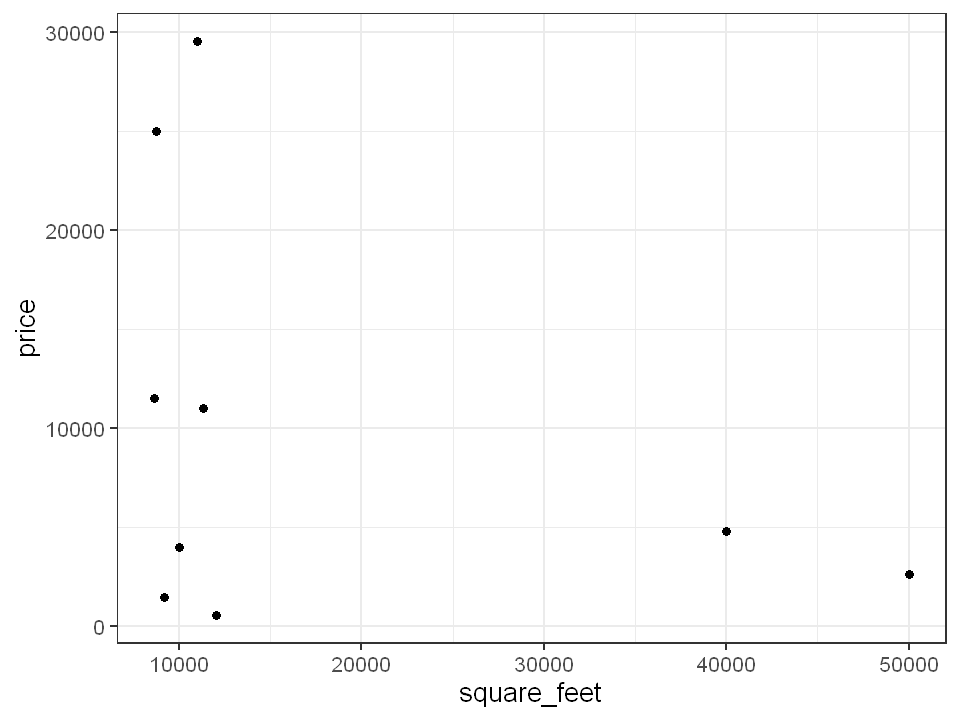

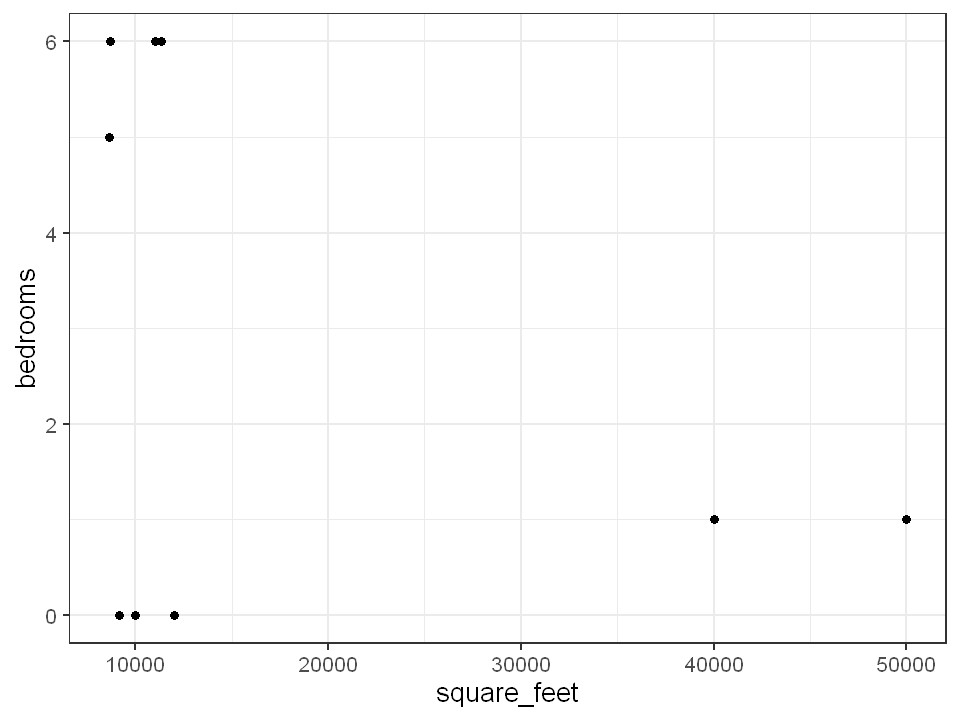

In [8]:
# Kiugró értékek keresése 2

# A magas értékek vizsgálata
dfc %>%
filter(square_feet > 8000) %>%
ggplot() +
geom_point(mapping = aes(x = square_feet, y = price)) +
theme_bw(base_size=16)

dfc %>%
filter(square_feet > 8000) %>%
ggplot() +
geom_point(mapping = aes(x = square_feet, y = bedrooms)) +
theme_bw(base_size=16)

# Konklúzió:
# Nem feltétlenül irreális értékek. Lehetséges, hogy telkekről
# és nagy villákról van szó (10000ft^2 ~ 900m^2)

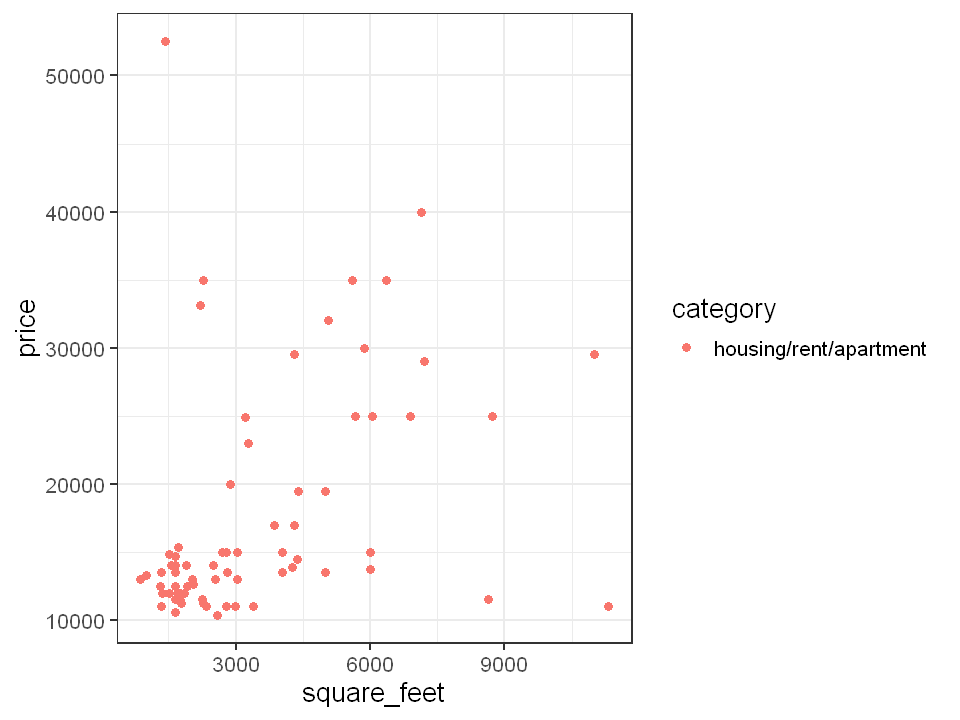

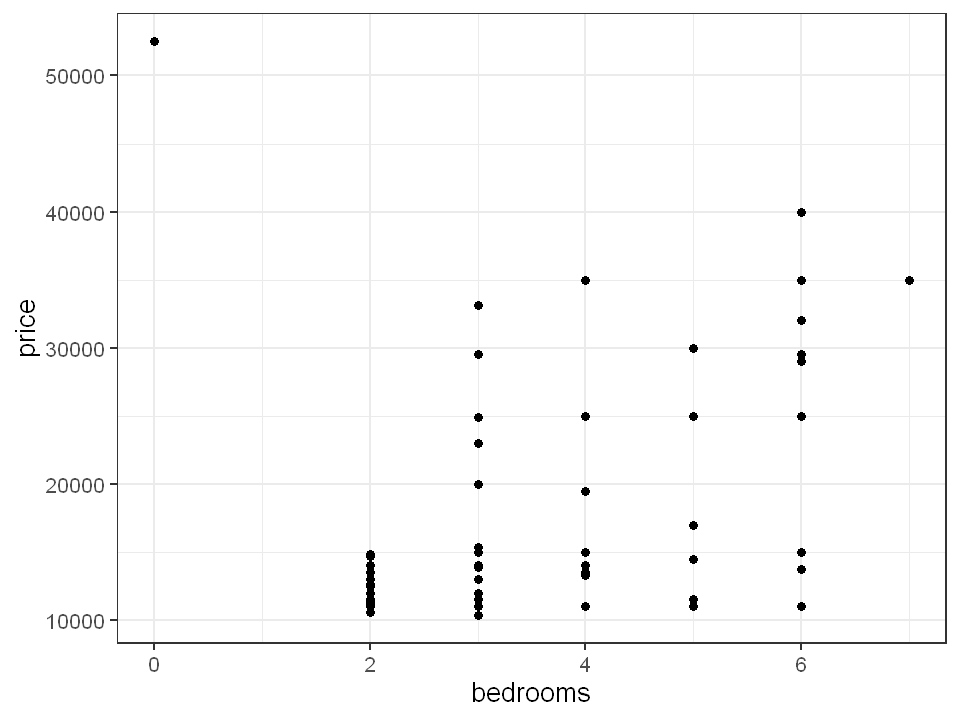

In [9]:
# Kiugró értékek keresése 3

# A magas értékek vizsgálata
dfc %>%
filter(price > 10000) %>%
ggplot() +
geom_point(mapping = aes(x = square_feet, y = price, color = category)) +
theme_bw(base_size=16)

dfc %>%
filter(price > 10000) %>%
ggplot() +
geom_point(mapping = aes(x = bedrooms, y = price)) +
theme_bw(base_size=16)

# Konklúzió:
# Ezek sem feltétlenül irreális értékek, kivéve a legdrágábbat. Lehetséges, hogy luxus villák is vannak hirdetve

dfc = filter(dfc, price < 50000)

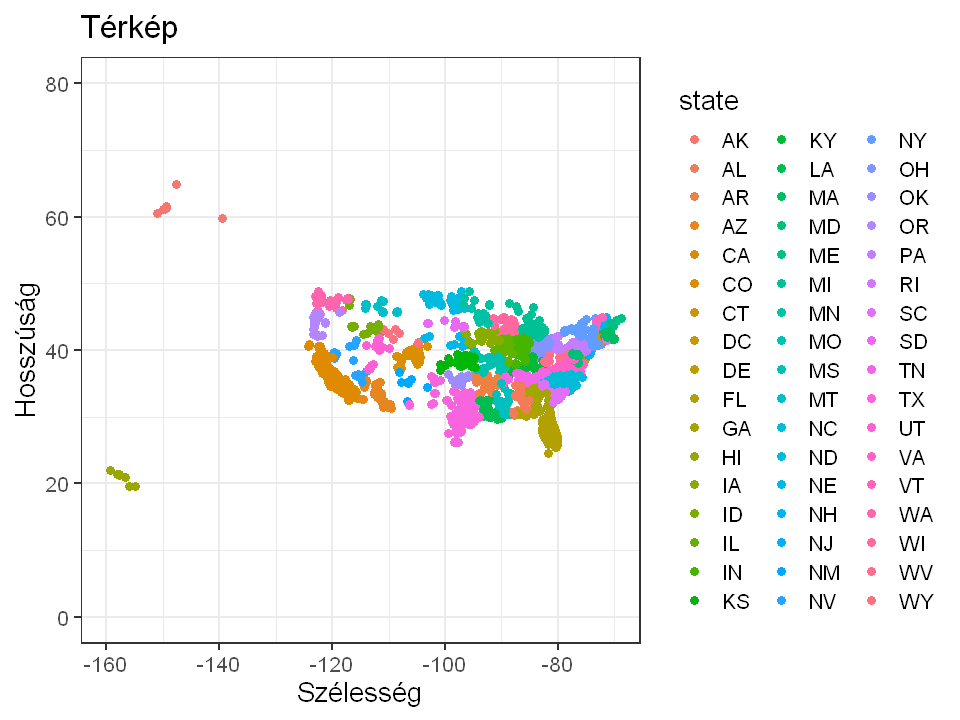

In [10]:
# Lat, long és state vizsgálat

dfc %>%
filter(!is.na(state)) %>%
ggplot() +
geom_point(mapping = aes(x = longitude, y = latitude, color = state)) +
coord_cartesian(xlim=c(-160,-70), ylim=c(0,80)) +
xlab("Szélesség") +
ylab("Hosszúság") +
ggtitle("Térkép") + 
theme_bw(base_size = 16)

# Konklúzió:
# Nincs nagyon kiugró érték, szépen látszanak az államok, és az USA térképe is kirajzolódik

In [11]:
# Amenities (felszereltség) kategória kezelése

dfc %>% 
filter(!is.na(amenities)) %>%
select(amenities) %>%
count(amenities) %>%
filter(n > 400) %>%
arrange(desc(n))

amenities,n
<chr>,<int>
Parking,6204
"Parking,Storage",2117
"Gym,Pool",1873
Pool,1483
"Gym,Parking,Pool",1191
"Parking,Pool",889
Washer Dryer,843
Patio/Deck,776
"Clubhouse,Gym,Pool",768


In [12]:
# A vizsgálat alapján a legnépszerűbb felszereltségek beállítása

dfc = mutate(dfc,
             parking = factor(grepl("Parking", amenities, fixed = TRUE)),
             pool = factor(grepl("Pool", amenities, fixed = TRUE)),
             gym = factor(grepl("Gym", amenities, fixed = TRUE)),
             patio = factor(grepl("Patio/Deck", amenities, fixed = TRUE)),
             washer = factor(grepl("Washer Dryer", amenities, fixed = TRUE)))

dfc = mutate(dfc,
             parking = fct_recode(parking, "No" = "FALSE", "Yes" = "TRUE"),
             pool = fct_recode(pool, "No" = "FALSE", "Yes" = "TRUE"),
             gym = fct_recode(gym, "No" = "FALSE", "Yes" = "TRUE"),
             patio = fct_recode(patio, "No" = "FALSE", "Yes" = "TRUE"),
             washer = fct_recode(washer, "No" = "FALSE", "Yes" = "TRUE"))

dfc = select(dfc, -amenities)

summary(dfc)

                           category       bathrooms        bedrooms    
 housing/rent                  :    7   Min.   :1.000   Min.   :0.000  
 housing/rent/apartment        :99700   1st Qu.:1.000   1st Qu.:1.000  
 housing/rent/commercial/retail:   42   Median :1.000   Median :2.000  
 housing/rent/condo            :    3   Mean   :1.445   Mean   :1.728  
 housing/rent/home             :    4   3rd Qu.:2.000   3rd Qu.:2.000  
 housing/rent/other            :    1   Max.   :9.000   Max.   :9.000  
 housing/rent/short_term       :    4                                  
  fee            has_photo     pets_allowed     price       price_display  
 No :99560   No       : 9256   Yes:39148    Min.   :  100   Min.   :  100  
 Yes:  201   Thumbnail:34347   No :60613    1st Qu.: 1014   1st Qu.: 1014  
             Yes      :56158                Median : 1350   Median : 1350  
                                            Mean   : 1527   Mean   : 1527  
                                            

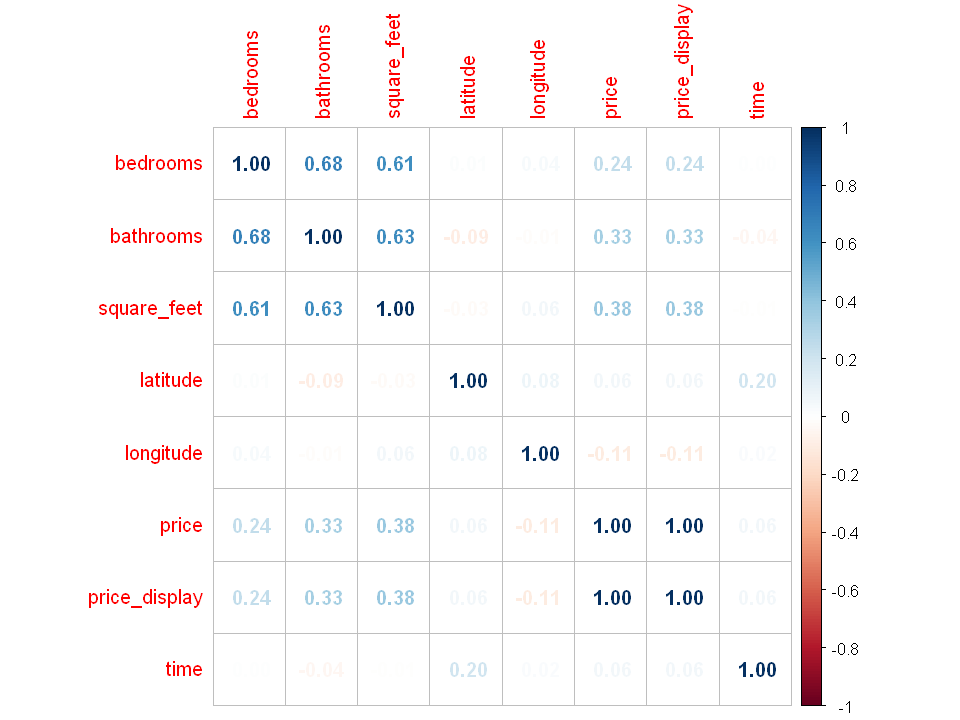

In [13]:
# Numerikus értékek korrelációs vizsgálata

sac_corr = dfc %>% 
select(bedrooms, bathrooms, square_feet, latitude, longitude, price, price_display, time)

mat = cor(sac_corr)
corrplot(mat, method="number")

# Konklúzió:
# Vannak nagyobb korrelációk, pl. háló- és fürdőszobák száma között. Nem szükséges manuális eldobás.

dfc = select(dfc, -price_display)

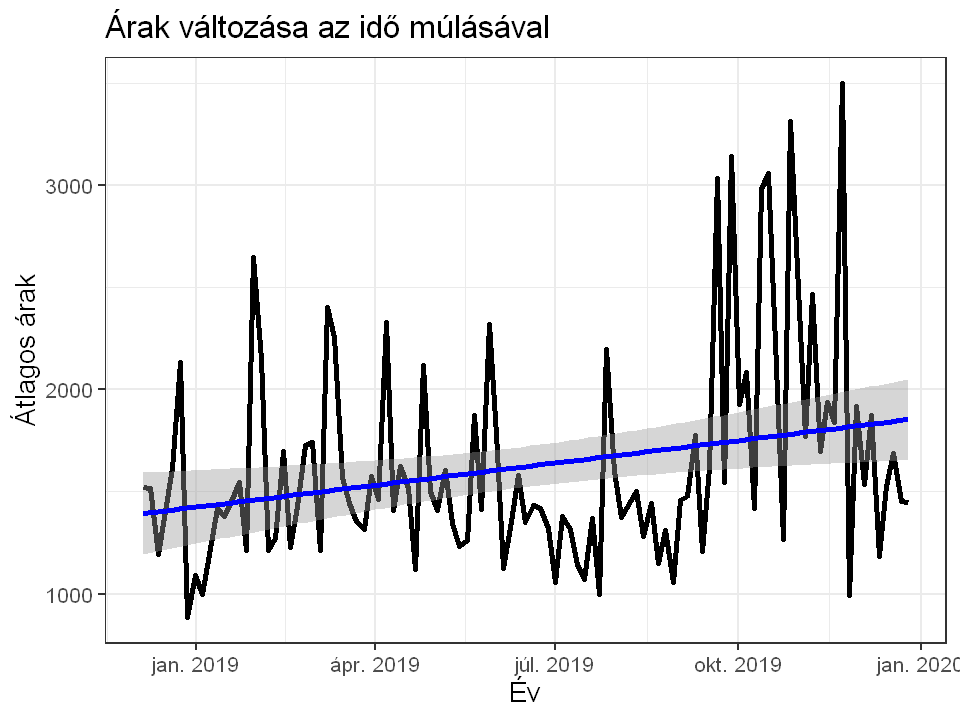

In [16]:
# Árak vizsgálata az idő múlásával

step = 320000

dfc %>%
group_by(tm = as.integer(time/step)) %>%
summarize(atlag_price = mean(price)) %>%
ggplot() + 
geom_line(aes(x = as_datetime(tm*step), y = atlag_price), linewidth = 1.5) + 
geom_smooth(mapping = aes(x = as_datetime(tm*step), y = atlag_price), method='lm', formula = y ~ x, color = 'blue') +
xlab("Év") +
ylab("Átlagos árak") +
ggtitle("Árak változása az idő múlásával") + 
theme_bw(base_size = 16)

# Konklúzió:
# Jól láthatóan növekednek az átlag árak, azonban van egy furcsán nagy ugrás a késő őszi időszakban

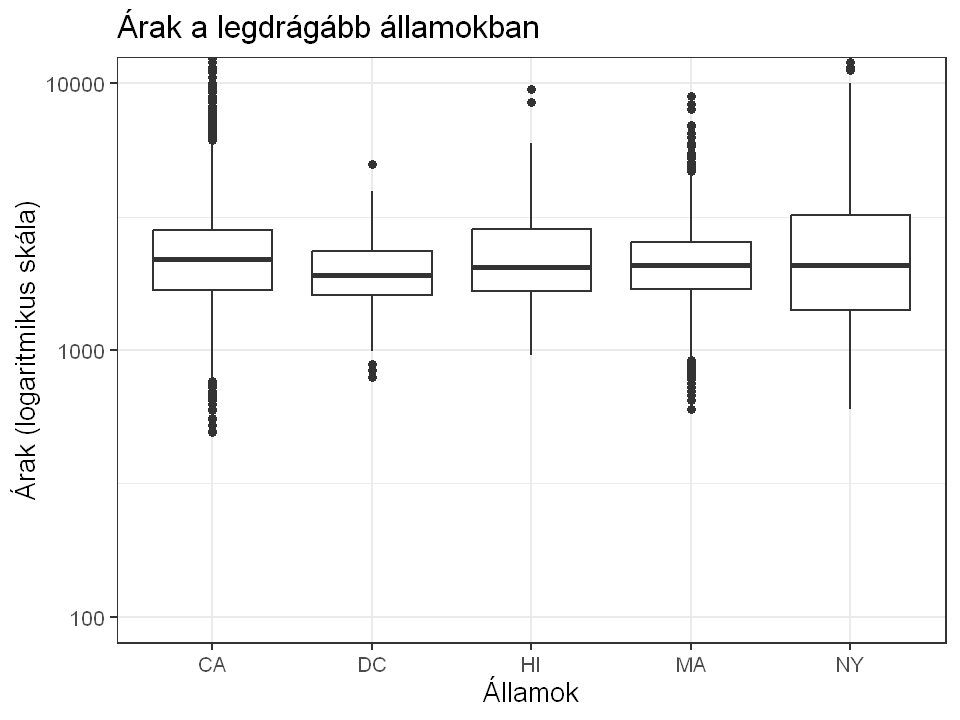

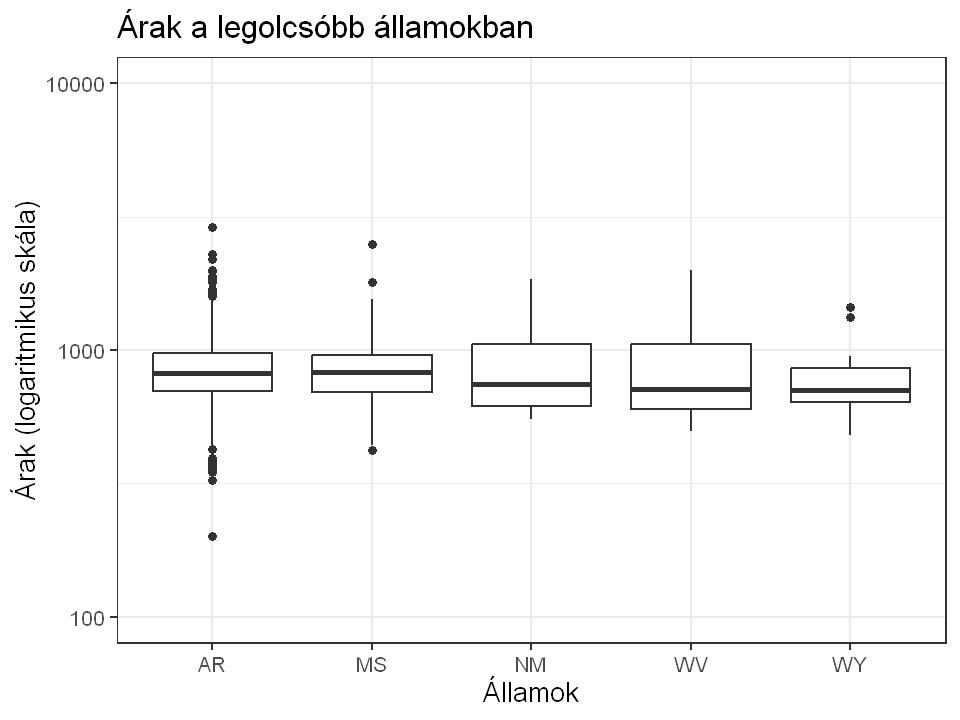

In [17]:
# Árak vizsgálata az egyes államokban (state)

expensive_states = dfc %>%
filter(!is.na(state)) %>%
select(price, state) %>%
group_by(state) %>%
summarize(atlag_price = mean(price)) %>%
arrange(desc(atlag_price))

top = head(expensive_states$state, 5)

cheap_states = expensive_states %>%
arrange(atlag_price)

bot = head(cheap_states$state, 5)

dfc %>%
filter(!is.na(state), state %in% top) %>%
ggplot() + 
geom_boxplot(mapping = aes(x = state, y = price)) +
scale_y_log10() +
coord_cartesian(ylim=c(100, 10000)) +
xlab("Államok") +
ylab("Árak (logaritmikus skála)") +
ggtitle("Árak a legdrágább államokban") + 
theme_bw(base_size = 16)

dfc %>%
filter(!is.na(state), state %in% bot) %>%
ggplot() + 
geom_boxplot(mapping = aes(x = state, y = price)) +
scale_y_log10() +
coord_cartesian(ylim=c(100, 10000)) +
xlab("Államok") +
ylab("Árak (logaritmikus skála)") +
ggtitle("Árak a legolcsóbb államokban") + 
theme_bw(base_size = 16)

# Konklúzió:
# Jól látható, hogy az egyes államokban mekkora különbség érhető el az árak alapján

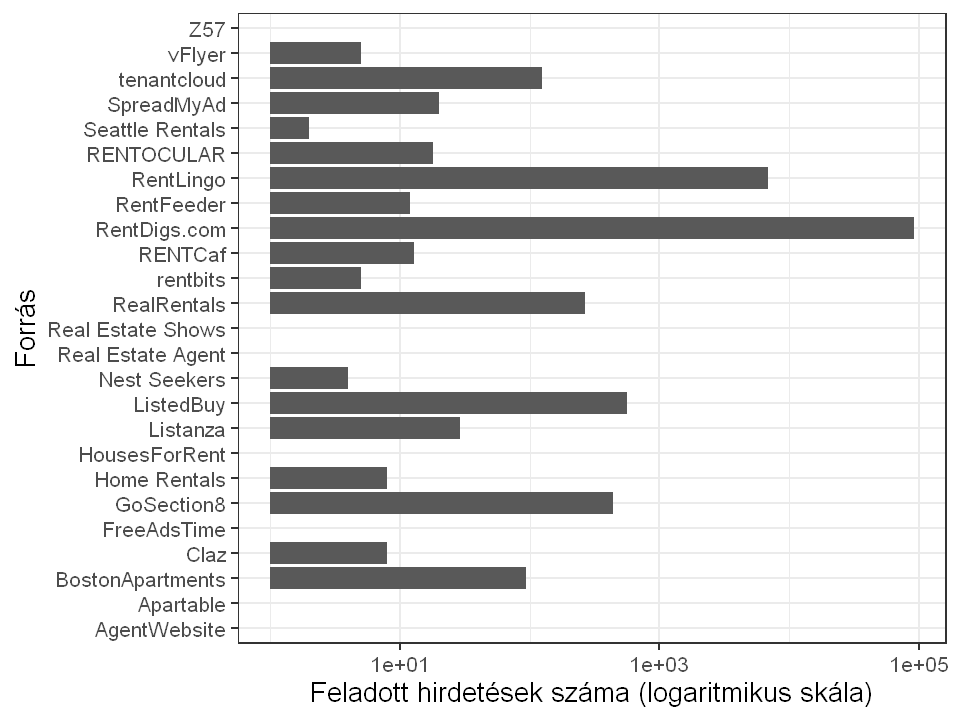

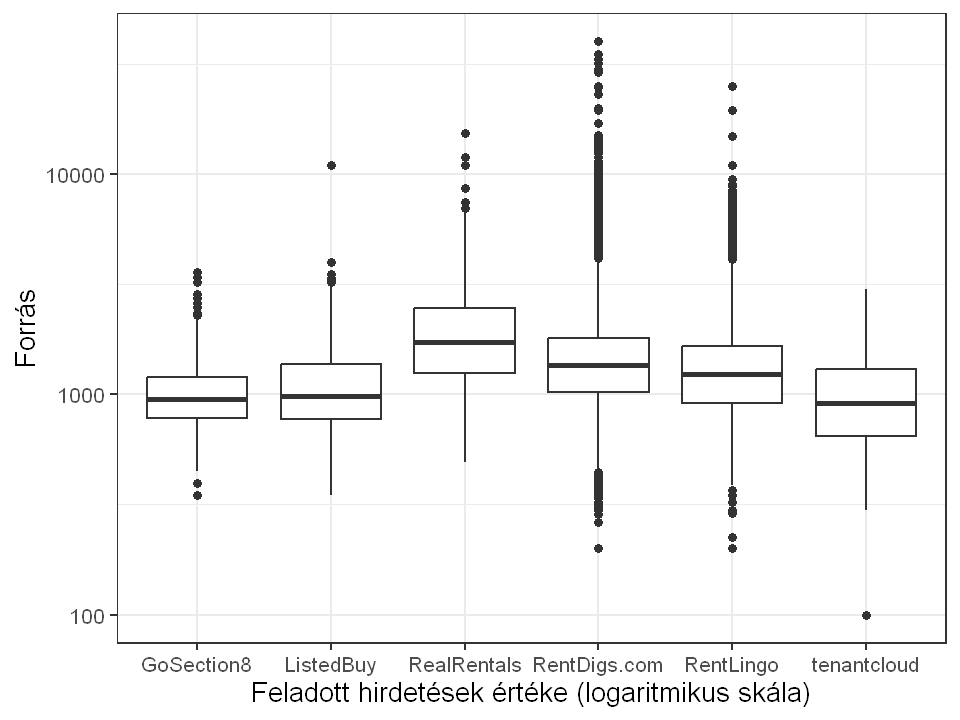

In [18]:
# Források (source) vizsgálata

dfc %>%
filter(!is.na(source)) %>%
select(source) %>%
ggplot() +
geom_bar(mapping = aes(x = source)) +
scale_y_log10() +
xlab("Forrás") +
ylab("Feladott hirdetések száma (logaritmikus skála)") +
coord_flip() + 
theme_bw(base_size = 16)

high_traffic = dfc %>%
filter(!is.na(source)) %>%
count(source) %>%
filter(n > 100)

dfc %>%
filter(source %in% high_traffic$source) %>%
select(source, price) %>%
ggplot() +
geom_boxplot(mapping = aes(x = source, y = price)) +
scale_y_log10() +
xlab("Feladott hirdetések értéke (logaritmikus skála)") +
ylab("Forrás") +
theme_bw(base_size = 16)

In [21]:
# Modellezés előkészítése - package

library(tidymodels)

In [22]:
# Modellezés előkészítése - adatok

dft = dfc

# Felbontás tanító és tesztelő halmazokra
data_split = initial_split(dft, prop=0.75)

# Lekérdezhetjük a részeket külön-külön
sac_train = training(data_split)
sac_test  = testing(data_split)

nrow(sac_train)/nrow(df)

[1] 0.7495041

In [27]:
# Lineáris regresszió

# Recept
linear_recept = recipe(price ~ ., data=sac_train) %>%
  step_integer(category) %>%
  step_integer(fee) %>%
  step_integer(has_photo) %>%
  step_integer(pets_allowed) %>%
  step_integer(cityname) %>%
  step_integer(state) %>%
  step_integer(source) %>%
  step_integer(parking) %>%
  step_integer(pool) %>%
  step_integer(gym) %>%
  step_integer(patio) %>%
  step_integer(washer) %>%
  step_corr(all_numeric_predictors(), threshold = .9) %>%
  prep()

# Tanítás
fit_linear = linear_reg() %>%
set_engine("lm") %>%
set_mode("regression") %>% 
fit(price ~ ., data = bake(linear_recept, sac_train))

# Tesztelés
fit_linear %>%
predict(bake(linear_recept, sac_test)) %>%
bind_cols(sac_test) %>%
select(price, .pred) %>%
mae(price, .pred)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
mae,standard,479.4228


In [24]:
# KNN modell numerikus értékekkel

# Recept, ahol csak numerikus értékek szerepelnek
knn_recept = recipe(price ~ square_feet + bathrooms + bedrooms + latitude + longitude + time, data=sac_train) %>%
  step_center(square_feet, bathrooms, bedrooms, latitude, longitude, time) %>%
  step_scale(square_feet, bathrooms, bedrooms, latitude, longitude, time) %>%
  prep()

# Tanítás
fit_knn = nearest_neighbor(mode = "regression", neighbors = 5) %>%
set_engine("kknn") %>% 
fit(price ~ square_feet + bathrooms + bedrooms + latitude + longitude + time, data = bake(knn_recept, sac_train))

# Tesztelés
fit_knn %>% 
predict(bake(knn_recept, sac_test)) %>%
bind_cols(sac_test) %>%
mae(price, .pred)

Warning message:
"package 'kknn' was built under R version 4.5.3"


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
mae,standard,232.1786


In [424]:
# Modell TODO?

recept = dft %>%
recipe(price ~ .) %>%
  step_integer(category) %>%
  step_integer(fee) %>%
  step_integer(has_photo) %>%
  step_integer(pets_allowed) %>%
  step_integer(cityname) %>%
  step_integer(state) %>%
  step_integer(source) %>%
  step_integer(parking) %>%
  step_integer(pool) %>%
  step_integer(gym) %>%
  step_integer(patio) %>%
  step_integer(washer) %>%
step_corr(all_numeric_predictors(), threshold = .9) %>%
prep()

tidy(recept)

recept %>%
bake(new_data = NULL) %>%
head(2)

number,operation,type,trained,skip,id
<int>,<chr>,<chr>,<lgl>,<lgl>,<chr>
1,step,integer,TRUE,FALSE,integer_2xQUn
2,step,integer,TRUE,FALSE,integer_2LLM4
3,step,integer,TRUE,FALSE,integer_z6wuW
4,step,integer,TRUE,FALSE,integer_nuXGJ
5,step,integer,TRUE,FALSE,integer_gQvZE
6,step,integer,TRUE,FALSE,integer_ovSOY
7,step,integer,TRUE,FALSE,integer_8vlGZ
8,step,integer,TRUE,FALSE,integer_GmQX7
9,step,integer,TRUE,FALSE,integer_DqdOL


category,bathrooms,bedrooms,fee,has_photo,pets_allowed,square_feet,cityname,state,latitude,longitude,source,time,parking,pool,gym,patio,washer,price
<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>
2,1.0,1,1,2,1,542,2202,5,33.8520,-118.3759,19,1577360355,1,1,1,1,1,2195
2,1.5,3,1,2,1,1500,1834,46,37.0867,-76.4941,19,1577360340,1,1,1,1,1,1250
